<a href="https://colab.research.google.com/github/AkhileshSR/AkhileshSR/blob/main/022026_08_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

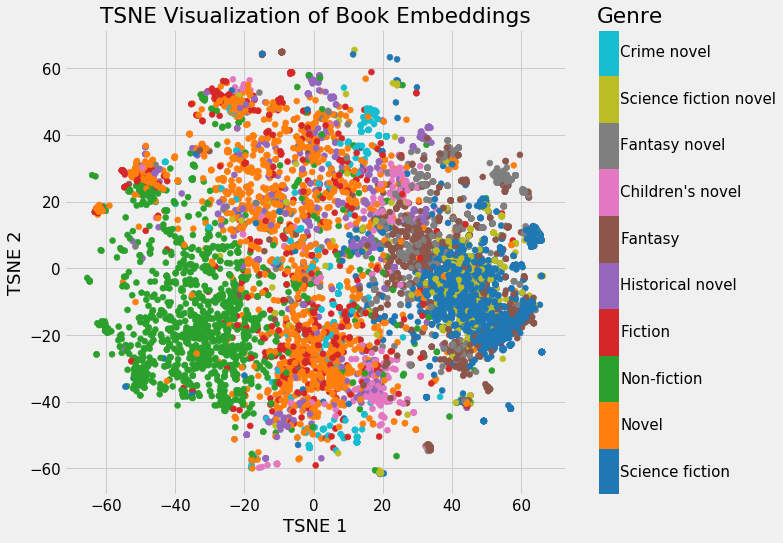

## 1. Install dependencies & import libraries

In [ ]:
# Install required libraries
%pip install openai scikit-learn matplotlib --quiet

In [ ]:
import getpass

api_key = getpass.getpass("Enter your OpenAI API Key: ")
print("API key received!")  # This will not print the key itself

In [ ]:
# Import required modules
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Initialize OpenAI client (uses your environment/API key)
client = OpenAI(api_key=api_key)

## 2. Helper function to convert text → embedding vector

In [ ]:
# This function takes text as input and returns its embedding vector.
def get_embedding(text):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )
    # Each embedding is a list of numbers representing meaning
    return response.data[0].embedding

## 3. Example 1 — Word embeddings (CAT, DOG, APPLE)

In [ ]:
# Get embeddings for individual words
cat_emb = get_embedding("cat")
dog_emb = get_embedding("dog")
apple_emb = get_embedding("apple")

# Display how long an embedding vector is
print("Length of embedding vector:", len(cat_emb))

# Show first few numbers to indicate it's numeric representation
print("First few numbers for 'cat':", cat_emb[:5])

print("First few numbers for 'dog':", dog_emb[:5])

## 4. Function to compute similarity between two vectors

In [ ]:
# Computes cosine similarity between two embedding vectors.
# Higher value means the two texts have similar meaning.
def similarity(a, b):
    return cosine_similarity([a], [b])[0][0]

## 5. Compare similarity between CAT, DOG, and APPLE

In [ ]:
# Similarity between semantically close words
sim_cat_dog = similarity(cat_emb, dog_emb)

# Similarity between unrelated words
sim_cat_apple = similarity(cat_emb, apple_emb)

print("Similarity(cat, dog)   =", round(sim_cat_dog, 2))
print("Similarity(cat, apple) =", round(sim_cat_apple, 2))

## 6. Simple visual diagram (manually plotted for intuition)

(This is not real embedding space — just a conceptual plot to demonstrate “closer meaning = closer points”)

In [ ]:
# Coordinates chosen manually only for teaching conceptual similarity
x = [0, 0.4, 2.5]      # cat, dog, apple
y = [0, 0.2, 1.2]
labels = ["cat", "dog", "apple"]

plt.figure(figsize=(5,5))
plt.scatter(x, y)

# Add labels next to points for clarity
for i in range(len(labels)):
    plt.text(x[i] + 0.05, y[i] + 0.05, labels[i], fontsize=12)

plt.title("Conceptual Visual: Similar words appear closer")
plt.show()

## 7. Example 2 — Sentence embeddings

In [ ]:
# Sentences with related meaning
s1 = get_embedding("A cat drinks milk")
s2 = get_embedding("A dog eats bones")

# Sentence with unrelated meaning
s3 = get_embedding("The car is fast")

# Compare similarity between sentences
print("Similarity(s1, s2) =", round(similarity(s1, s2), 2))  # related sentences
print("Similarity(s1, s3) =", round(similarity(s1, s3), 2))  # unrelated sentences

## 8. Example 3 — Resume vs Job Description

In [ ]:
resume_text = "I am a backend engineer skilled in Python and Flask"
jd_text      = "We need a Python backend developer who knows Flask"

resume_emb = get_embedding(resume_text)
jd_emb     = get_embedding(jd_text)

print("Resume–JD Similarity =", round(similarity(resume_emb, jd_emb), 2))

## 9. Ranking multiple resumes

In [ ]:
# Three sample resumes
r1 = "Marketing manager with marketing skills"
r2 = "Backend engineer experienced with Python and Flask"
r3 = "Data scientist working with machine learning in python"


# Get embeddings
r1_emb = get_embedding(r1)
r2_emb = get_embedding(r2)
r3_emb = get_embedding(r3)

# Job description for matching
jd_text = "Looking for backend engineer with Python and Flask"
jd_emb = get_embedding(jd_text)

# Compute similarity for each resume
sim_r1 = similarity(r1_emb, jd_emb)
sim_r2 = similarity(r2_emb, jd_emb)
sim_r3 = similarity(r3_emb, jd_emb)

print("Marketing manager:", round(sim_r1, 2))
print("Python/Flask resume similarity:", round(sim_r2, 2))
print("Data science resume similarity:", round(sim_r3, 2))

## 10. Visualize resume match scores

In [ ]:
labels = ["Marketing Manager", "Python/Flask Resume", "Data Science Resume"]
values = [sim_r1, sim_r2, sim_r3]

plt.barh(labels, values)
plt.xlabel("Similarity Score")
plt.title("Resume vs JD Matching")
plt.show()